In [226]:
import numpy as np

class CliffWalking:
    def __init__(self, rows, cols):
        self.rows = rows
        self.cols = cols

        self.start_state = (rows - 1, 0)
        self.goal_state = (self.rows - 1, self.cols - 1)

        self.cliff_states = [(self.rows - 1 , i) for i in range(1, self.cols - 1)]

        self.actions = {
           0: (-1, 0),
           1: (1, 0),
           2: (0, -1),
           3: (0, 1)
        }

        self.num_actions = len(self.actions)
        self.num_state = self.rows * self.cols
        self.current_state = self.start_state

    def reset(self):
        self.current_state = self.start_state
        return self.current_state
    
    def render(self):
        grid = np.full((self.rows, self.cols), '-', dtype=str)

        for (row, col) in self.cliff_states:
            grid[row, col] = 'C'
        grid[self.start_state] = 'S'
        grid[self.goal_state] = 'G'
        grid[self.current_state] = 'A'

        for row in grid:
            print(' '.join(row))
        print("-" * 30)

    def step(self, action: int) -> tuple:
        row, column = self.current_state
        dr, dc = self.actions[action]

        new_row = row + dr
        new_col = column + dc

        if new_row < 0 or new_row >= self.rows or new_col < 0 or new_col >= self.cols:
            new_row, new_col = row, column

        next_state = (new_row, new_col)

        if next_state == self.goal_state:
            reward = 0
            done = True
            self.current_state = next_state 

        elif next_state in self.cliff_states:
            reward = -1
            reward = -100
            done = False

            self.current_state = self.start_state
            next_state = self.start_state

        # elif next_state[0] == self.rows - 2:
        #     reward = -20
        #     done = False
        #     self.current_state = next_state

        else:
            reward = -1
            done = False
            self.current_state = next_state

        return next_state, reward, done

In [227]:
class RLAgent:
    def __init__(self, env, alpha = 0.1, gamma = 1.0, epsilon = 0.1):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

        self.q_table = np.zeros((self.env.rows, self.env.cols, self.env.num_actions))

    def choose_action(self, state):
        row, column = state

        if np.random.uniform(0, 1) < self.epsilon:
            return np.random.randint(self.env.num_actions)
        
        else:
            q_values = self.q_table[row, column, :]
            max_q = np.max(q_values)

            best_actions = np.where(q_values == max_q)[0]
            return np.random.choice(best_actions)


In [228]:
class QLearningAgent(RLAgent):
    def update(self, state, action, reward, next_state):
        row, column = state
        next_row, next_column = next_state

        best_next_q = np.max(self.q_table[next_row, next_column, :])

        td_target = reward + self.gamma * best_next_q
        td_error = td_target - self.q_table[row, column, action]
        self.q_table[row, column, action] += self.alpha * td_error  

class SarsaAgent(RLAgent):
    def update(self, state, action, reward, next_state, next_action):
        row, column = state
        next_row, next_column = next_state

        next_q = self.q_table[next_row, next_column, next_action]

        td_target = reward + self.gamma * next_q
        td_error = td_target - self.q_table[row, column, action]
        self.q_table[row, column, action] += self.alpha * td_error

In [229]:
def train_agent(env, agent, episodes = 5000, is_sarsa = False):
    rewards_per_episode = []

    for ep in range(episodes):
        state = env.reset()
        ep_reward = 0
        done = False

        action = agent.choose_action(state)

        while not done:
            next_state, reward, done = env.step(action)
            ep_reward += reward

            if is_sarsa:
                next_action = agent.choose_action(next_state)
                agent.update(state, action, reward, next_state, next_action)
                action = next_action
            else:
                agent.update(state, action, reward, next_state)
                action = agent.choose_action(next_state)

            state = next_state

        rewards_per_episode.append(ep_reward)

    return rewards_per_episode

In [ ]:
def train_agent_with_decay(env, agent, episodes = 5000, is_sarsa = False):
    rewards_per_episode = []

    for ep in range(episodes):
        state = env.reset()
        ep_reward = 0
        done = False

        agent.epsilon = min(0.1, 1.0 / (ep + 1))
        
        action = agent.choose_action(state)

        while not done:
            next_state, reward, done = env.step(action)
            ep_reward += reward

            if is_sarsa:
                next_action = agent.choose_action(next_state)
                agent.update(state, action, reward, next_state, next_action)
                action = next_action
            else:
                agent.update(state, action, reward, next_state)
                action = agent.choose_action(next_state)

            state = next_state

        rewards_per_episode.append(ep_reward)

    return rewards_per_episode

In [231]:
def visualize_policy(agent, title):
    arrows = {0: '↑', 1: '↓', 2: '←', 3: '→'}
    grid = np.full((agent.env.rows, agent.env.cols), ' ', dtype=object)

    for row in range(agent.env.rows):
        for col in range(agent.env.cols):
            if (row, col) in agent.env.cliff_states:
                grid[row, col] = 'C'
            elif (row, col) == agent.env.goal_state:
                grid[row, col] = 'G'
            else:
                best_action = np.argmax(agent.q_table[row, col])
                grid[row, col] = arrows[best_action]
    print(f"=== {title} ===")
    for row in grid:
        print(" ".join(row))
    print("\n")

In [232]:
env_q = CliffWalking(4, 12)
agent_q = QLearningAgent(env_q, alpha=0.1, gamma=1.0, epsilon=0.1)

env_sarsa = CliffWalking(4, 12)
agent_sarsa = SarsaAgent(env_sarsa, alpha=0.1, gamma=1.0, epsilon=0.1)

np.random.seed(42)

rewards_q = train_agent(env_q, agent_q)

rewards_sarsa = train_agent(env_sarsa, agent_sarsa, is_sarsa=True)

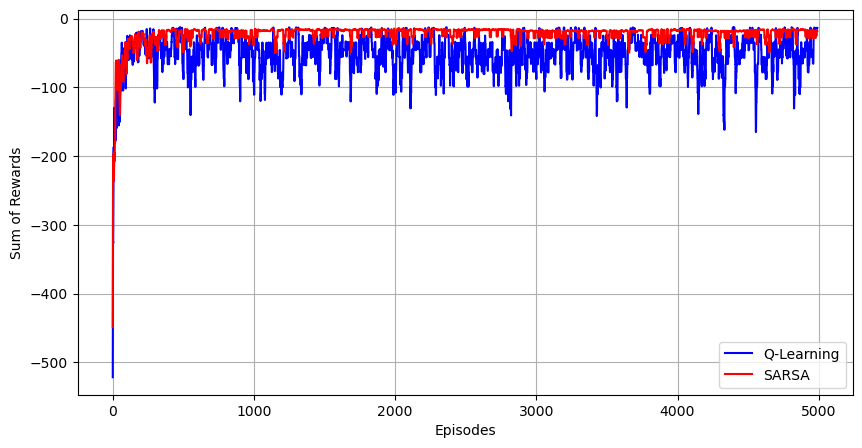

In [233]:
import matplotlib.pyplot as plt

def moving_average(data, window_size = 10):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(moving_average(rewards_q), label="Q-Learning", color="blue")
plt.plot(moving_average(rewards_sarsa), label="SARSA", color="red")

plt.xlabel("Episodes")
plt.ylabel("Sum of Rewards")
plt.legend()
plt.grid(True)
plt.show()

In [234]:
visualize_policy(agent_q, "Q-Learning Policy")
visualize_policy(agent_sarsa, "SARSA Policy")

=== Q-Learning Policy ===
→ ↑ → → → → ↑ → → → ↓ ↓
→ → ↓ → → ↓ ↓ → ↓ → → ↓
→ → → → → → → → → → → ↓
↑ C C C C C C C C C C G


=== SARSA Policy ===
→ → → → → → → → → → → ↓
→ → → → → ↑ → → → → → ↓
↑ ↑ ↑ → ↑ → ↑ ↑ ↑ ↑ → ↓
↑ C C C C C C C C C C G




In [235]:
env_decay = CliffWalking(4, 12)
agent_sarsa_decay = SarsaAgent(env_decay, alpha=0.1, gamma=1.0, epsilon=0.1)
rewards_decay = train_agent_with_decay(env_decay, agent_sarsa_decay, is_sarsa=True)
visualize_policy(agent_sarsa_decay, "SARSA with Epsilon Decay Policy")

=== SARSA with Epsilon Decay Policy ===
↓ ↓ → → → ↓ → → ↓ → → ↓
→ → → → → → → → → → → ↓
→ ↑ ↑ → ↑ ↑ → → → → → ↓
↑ C C C C C C C C C C G


